In [3]:
import subprocess
import os

root = ""

cur_path = os.path.abspath(".").split("/")

if cur_path[-1] == "notebooks" or cur_path[-2] == "cits4403-complex-pathfinding":
    root = ".."

storm_path = os.path.join(root, "src","Ant Simulation With Storm")
storm_executable = "Ant Simulation With Storm.exe"
no_storm_path = os.path.join(root, "src","Ant Simulation No Storm")
no_storm_executable = "Ant Simulation No Storm.exe"

# Ant Colony vs A* simulation instructions

Run the following code block to begin the ant colony simulation. You will note the black ant agents and the white A* agents
The black ants follow and deposit pheremones the keep track of where their fellow agents have been
The A* agents act entirely independantly using the A* algorithm for pathfinding

Once you notice the ants begining to construct a path, you can click the "Reset Data" button on the graph to restart the statistics tracking. This will provide a more accurate comparison of the two algorithms' ongoing performance, since the ant colony takes significantly longer to being successfully pathfinding.

Once satisfied with the amount of time the simulation has been running for, you can hit the "Export CSV" button in the graph menu. this will export the recorded data for further comparison.

To exit the simulation, hit ESC.


## Control comparison (No Storm)

The following simulation shows a raw comparison of the two algorithms with no dynamic weightings. You wil notice the storm still appears, however it does not influence the agents.

/mnt/c/Users/smile/OneDrive/Documents/Uni/cits4403/cits4403-complex-pathfinding/src/Ant Simulation No Storm
src/Ant Simulation No Storm/Ant Simulation No Storm.exe
[UnityMemory] Configuration Parameters - Can be set up in boot.config
    "memorysetup-bucket-allocator-granularity=16"
    "memorysetup-bucket-allocator-bucket-count=8"
    "memorysetup-bucket-allocator-block-size=4194304"
    "memorysetup-bucket-allocator-block-count=1"
    "memorysetup-main-allocator-block-size=16777216"
    "memorysetup-thread-allocator-block-size=16777216"
    "memorysetup-gfx-main-allocator-block-size=16777216"
    "memorysetup-gfx-thread-allocator-block-size=16777216"
    "memorysetup-cache-allocator-block-size=4194304"
    "memorysetup-typetree-allocator-block-size=2097152"
    "memorysetup-profiler-bucket-allocator-granularity=16"
    "memorysetup-profiler-bucket-allocator-bucket-count=8"
    "memorysetup-profiler-bucket-allocator-block-size=4194304"
    "memorysetup-profiler-bucket-allocator-block-

/tmp/ipykernel_6485/264429714.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


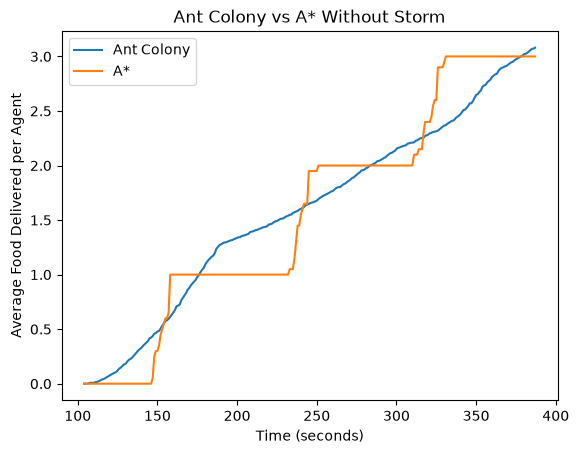

In [2]:

print (os.path.abspath(no_storm_path))
print (os.path.join(no_storm_path, no_storm_executable))
silence = subprocess.call(os.path.join(no_storm_path, no_storm_executable))

csv_dir = os.path.join(root, "data", "No_Storm_Statistics")
contents = os.listdir(csv_dir)

latest = ""

for file in contents:
    csv_path = os.path.join(csv_dir, file)
    if os.path.isfile(csv_path) and file.split(".")[1] == "csv":
        if csv_path > latest:
            latest = csv_path

import matplotlib.pyplot as plt
import pandas as pd

if latest == "":
    print("You forgot to generate a statistics file!")
else:
    dataframe = pd.read_csv(latest)

    fig, ax = plt.subplots()
    ax.plot(dataframe["time_seconds"], dataframe["ant_cumulative_food_per_agent"], label="Ant Colony")
    ax.plot(dataframe["time_seconds"], dataframe["astar_cumulative_food_per_agent"], label="A*")

    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels)
    plt.title("Ant Colony vs A* Without Storm")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Average Food Delivered per Agent")
    fig.show()


## Dynamic comparison (Storm)

The following simulation shows a comparison of the two algorithms with a dynamically weighted environment. You wil notice the storm displlays Dark and Light patches. Both ants and A* agents will be slowed in the darker areas of the storm, and A* agents will actively try to pathfind arounf the darker storm patches.

[UnityMemory] Configuration Parameters - Can be set up in boot.config
    "memorysetup-bucket-allocator-granularity=16"
    "memorysetup-bucket-allocator-bucket-count=8"
    "memorysetup-bucket-allocator-block-size=4194304"
    "memorysetup-bucket-allocator-block-count=1"
    "memorysetup-main-allocator-block-size=16777216"
    "memorysetup-thread-allocator-block-size=16777216"
    "memorysetup-gfx-main-allocator-block-size=16777216"
    "memorysetup-gfx-thread-allocator-block-size=16777216"
    "memorysetup-cache-allocator-block-size=4194304"
    "memorysetup-typetree-allocator-block-size=2097152"
    "memorysetup-profiler-bucket-allocator-granularity=16"
    "memorysetup-profiler-bucket-allocator-bucket-count=8"
    "memorysetup-profiler-bucket-allocator-block-size=4194304"
    "memorysetup-profiler-bucket-allocator-block-count=1"
    "memorysetup-profiler-allocator-block-size=16777216"
    "memorysetup-profiler-editor-allocator-block-size=1048576"
    "memorysetup-temp-allocator-siz

/tmp/ipykernel_5983/2349597644.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


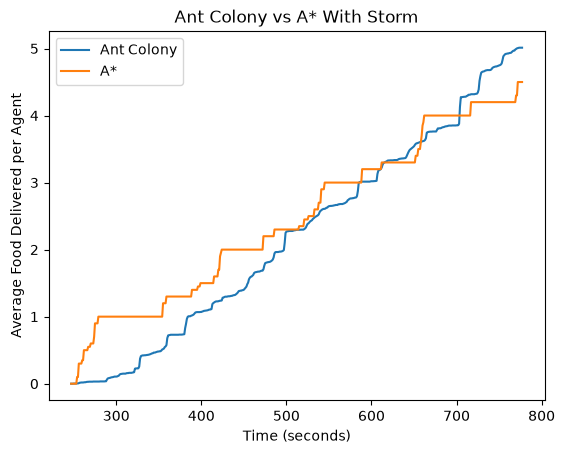

In [7]:
silence = subprocess.call(os.path.join(storm_path, storm_executable))

csv_dir = os.path.join(root, "data", "Storm_Statistics")
contents = os.listdir(csv_dir)

storm_latest = ""

for file in contents:
    csv_path = os.path.join(csv_dir, file)
    if os.path.isfile(csv_path) and file.split(".")[1] == "csv":
        if csv_path > storm_latest:
            storm_latest = csv_path

import matplotlib.pyplot as plt
import pandas as pd

if storm_latest == "":
    print("You forgot to generate a statistics file!")
else:
    storm_dataframe = pd.read_csv(storm_latest)

    fig, ax = plt.subplots()
    ax.plot(storm_dataframe["time_seconds"], storm_dataframe["ant_cumulative_food_per_agent"], label="Ant Colony")
    ax.plot(storm_dataframe["time_seconds"], storm_dataframe["astar_cumulative_food_per_agent"], label="A*")

    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels)
    plt.title("Ant Colony vs A* With Storm")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Average Food Delivered per Agent")
    fig.show()


### Ants no storm vs storm

See below a plot of the ants' performances between the two different environments. The starting point for each graph will vary depending on when the simulation data was reset.

/tmp/ipykernel_5983/811368500.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


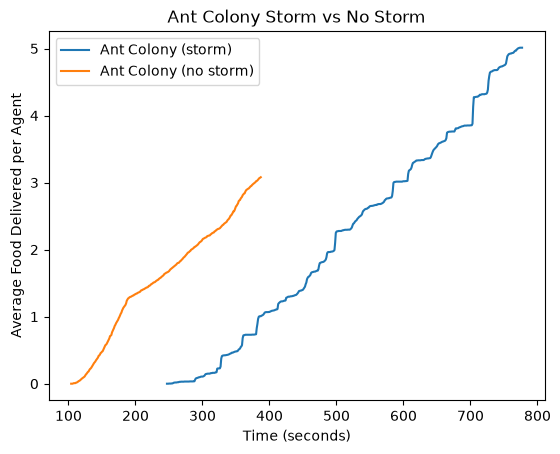

In [8]:

fig, ax = plt.subplots()
ax.plot(storm_dataframe["time_seconds"], storm_dataframe["ant_cumulative_food_per_agent"], label="Ant Colony (storm)")
ax.plot(dataframe["time_seconds"], dataframe["ant_cumulative_food_per_agent"], label="Ant Colony (no storm)")


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)
plt.title("Ant Colony Storm vs No Storm")
plt.xlabel("Time (seconds)")
plt.ylabel("Average Food Delivered per Agent")
fig.show()

### A* no storm vs storm

See below a plot of the A* agents' performances between the two different environments. The starting point for each graph will vary depending on when the simulation data was reset.

/tmp/ipykernel_5983/1114576897.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


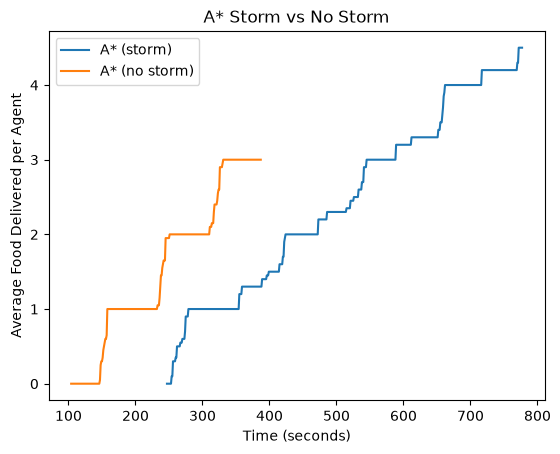

In [9]:
fig, ax = plt.subplots()
ax.plot(storm_dataframe["time_seconds"], storm_dataframe["astar_cumulative_food_per_agent"], label="A* (storm)")
ax.plot(dataframe["time_seconds"], dataframe["astar_cumulative_food_per_agent"], label="A* (no storm)")


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)
plt.title("A* Storm vs No Storm")
plt.xlabel("Time (seconds)")
plt.ylabel("Average Food Delivered per Agent")
fig.show()